
=== Informasi Dataset ===
Jumlah Baris : 45211
Jumlah Kolom : 17

Tipe Data Per Kolom:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
class        object
dtype: object

=== Cek Missing Value ===
Tidak ada missing value 😃

=== Distribusi Target (class) ===
class
no     39922
yes     5289
Name: count, dtype: int64


/tmp/ipython-input-1611743476.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette="pastel")


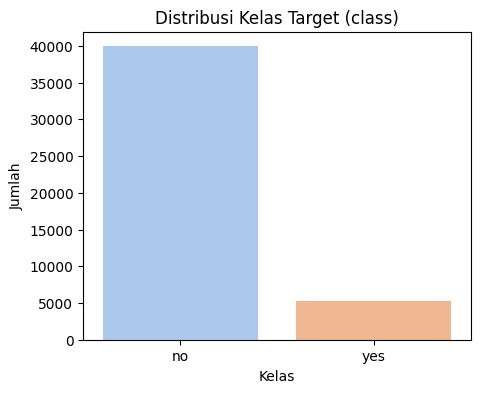


Dataset setelah encoding disimpan ke 'dataAfterEncode.csv'

Jumlah data training sebelum SMOTE: 31647
Jumlah data testing : 13564

Jumlah data training setelah SMOTE: 55890
Distribusi kelas setelah SMOTE:
 class
0    27945
1    27945
Name: count, dtype: int64


/tmp/ipython-input-1611743476.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette="pastel")


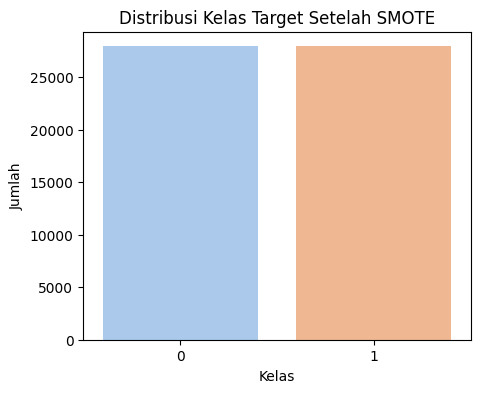


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.91      0.93     11977
           1       0.50      0.65      0.57      1587

    accuracy                           0.88     13564
   macro avg       0.73      0.78      0.75     13564
weighted avg       0.90      0.88      0.89     13564


=== Confusion Matrix ===


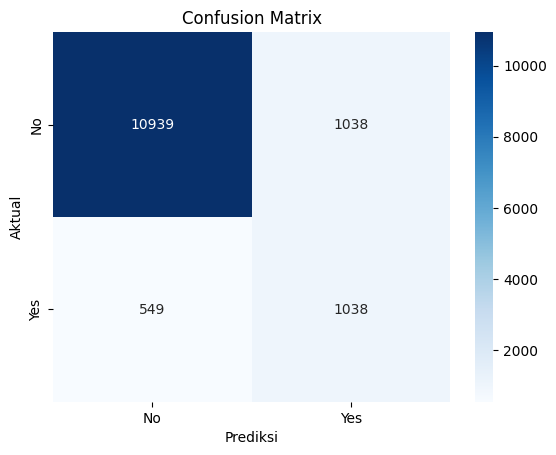

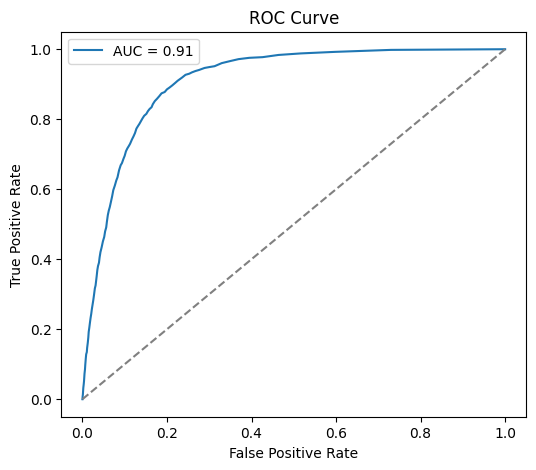

/tmp/ipython-input-1611743476.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importances.head(15), palette="viridis")


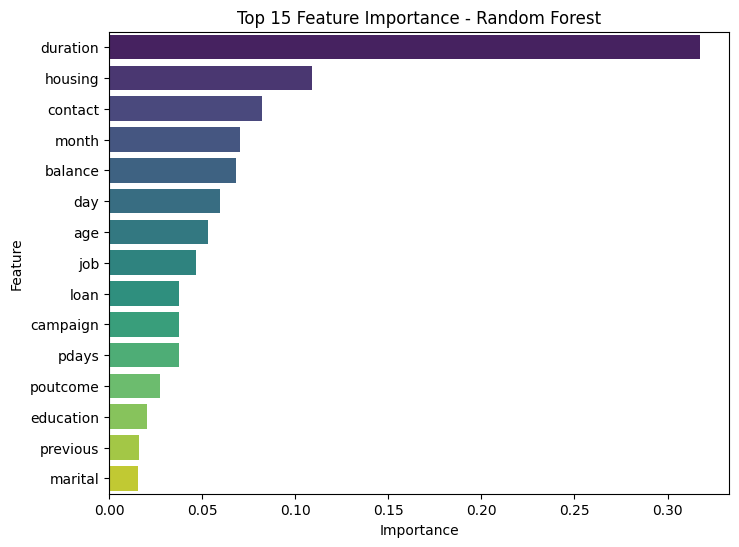


Flowchart berhasil dibuat: flowchart_fraud_randomforest.png


In [3]:
# =======================================================
# FRAUD DETECTION - BANK DATASET (Random Forest + Flowchart) == FIKSS
# =======================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
from graphviz import Digraph

# =======================================================
# 1. Load Dataset
# =======================================================
df = pd.read_csv("bank-full.csv", sep=",")

# =======================================================
# 2. Informasi Dataset & Cek Missing Value
# =======================================================
print("\n=== Informasi Dataset ===")
print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")
print("\nTipe Data Per Kolom:")
print(df.dtypes)

print("\n=== Cek Missing Value ===")
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("Tidak ada missing value 😃")
else:
    print(missing)

# =======================================================
# 3. Distribusi Target
# =======================================================
target_col = "class" # Set target column to 'class'
if target_col in df.columns:
    print(f"\n=== Distribusi Target ({target_col}) ===")
    print(df[target_col].value_counts())

    plt.figure(figsize=(5,4))
    sns.countplot(x=target_col, data=df, palette="pastel")
    plt.title(f"Distribusi Kelas Target ({target_col})")
    plt.xlabel("Kelas")
    plt.ylabel("Jumlah")
    plt.show()
else:
    print(f"Kolom target '{target_col}' tidak ditemukan di dataset.")


# =======================================================
# 4. Preprocessing
# =======================================================
# Encode variabel kategorikal
le = LabelEncoder()
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = le.fit_transform(df[col])

# Save the DataFrame after encoding
df.to_csv("dataAfterEncode.csv", index=False)
print("\nDataset setelah encoding disimpan ke 'dataAfterEncode.csv'")

# Pisahkan fitur & target
X = df.drop(target_col, axis=1)
y = df[target_col]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("\nJumlah data training sebelum SMOTE:", y_train.shape[0])
print("Jumlah data testing :", y_test.shape[0])

# =======================================================
# 5. SMOTE Oversampling
# =======================================================
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nJumlah data training setelah SMOTE:", y_train_res.shape[0])
print("Distribusi kelas setelah SMOTE:\n", y_train_res.value_counts())

# Visualisasi distribusi target setelah SMOTE
plt.figure(figsize=(5,4))
sns.countplot(x=y_train_res, palette="pastel")
plt.title("Distribusi Kelas Target Setelah SMOTE")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()


# =======================================================
# 6. Training Model Random Forest
# =======================================================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

# Prediksi
y_pred = rf.predict(X_test)

# =======================================================
# 7. Evaluasi Model
# =======================================================
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# ROC Curve
y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Feature Importance
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=importances.head(15), palette="viridis")
plt.title("Top 15 Feature Importance - Random Forest")
plt.show()

# =======================================================
# 8. Flowchart Penelitian (Graphviz)
# =======================================================
dot = Digraph(comment="Flowchart Penelitian Fraud Detection dengan Random Forest")
dot.attr(rankdir="TB", size="8")

dot.node("A", "Mulai", shape="oval", style="filled", color="lightgrey")
dot.node("B", "Load Data", shape="box", style="rounded,filled", color="lightblue")
dot.node("C", "Cek Data & Missing Value", shape="box", style="rounded,filled", color="lightblue")
dot.node("D", "Preprocessing (Encoding, Normalisasi)", shape="box", style="rounded,filled", color="lightblue")
dot.node("E", "Split Data (Train/Test)", shape="box", style="rounded,filled", color="lightblue")
dot.node("F", "SMOTE - Oversampling", shape="box", style="rounded,filled", color="lightblue")
dot.node("G", "Train Random Forest Model", shape="box", style="rounded,filled", color="lightgreen")
dot.node("H", "Evaluasi Model\n- Confusion Matrix\n- ROC Curve\n- Classification Report", shape="box", style="rounded,filled", color="orange")
dot.node("I", "Visualisasi\n- Distribusi Target\n- Feature Importance", shape="box", style="rounded,filled", color="orange")
dot.node("J", "Hasil & Kesimpulan", shape="box", style="rounded,filled", color="yellow")
dot.node("K", "Selesai", shape="oval", style="filled", color="lightgrey")

dot.edges(["AB", "BC", "CD", "DE", "EF", "FG", "GH", "HI", "IJ", "JK"])
dot.render("flowchart_fraud_randomforest", format="png", cleanup=True)

print("\nFlowchart berhasil dibuat: flowchart_fraud_randomforest.png")